In [39]:
import pandas as pd
import numpy as np

X_train = pd.read_csv(r"C:\Research\EndpointXAI\data\X_train.csv")
X_test = pd.read_csv(r"C:\Research\EndpointXAI\data\X_test.csv")
y_train = pd.read_csv(r"C:\Research\EndpointXAI\data\y_train.csv").squeeze()
y_test = pd.read_csv(r"C:\Research\EndpointXAI\data\y_test.csv").squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {y_train.unique()}")

Train: (36497, 10), Test: (9125, 10)
Classes: <StringArray>
['lateral_movement', 'defense_evasion', 'persistence']
Length: 3, dtype: str


In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Save the mapping so we can decode later
label_map = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))
print("Label mapping:")
print(label_map)

Label mapping:
{np.int64(0): 'defense_evasion', np.int64(1): 'lateral_movement', np.int64(2): 'persistence'}


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
import time

# Encode any string columns (some features may be raw strings from feature engineering)
string_cols = X_train.select_dtypes(include=['object']).columns.tolist()
if string_cols:
    print(f"Encoding string columns: {string_cols}")
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[string_cols] = oe.fit_transform(X_train[string_cols])
    X_test[string_cols] = oe.transform(X_test[string_cols])

print("Training Random Forest... ⏳")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_enc)

print(f"Done in {time.time()-start:.1f} seconds ✅")

Encoding string columns: ['Channel', 'SourceName', 'SourceModuleName', 'Severity', 'AccountName', 'AccountType']
Training Random Forest... ⏳


C:\Users\belba\AppData\Local\Temp\ipykernel_31144\4252074982.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  string_cols = X_train.select_dtypes(include=['object']).columns.tolist()


Done in 0.5 seconds ✅


In [42]:
from sklearn.metrics import classification_report, accuracy_score

rf_predictions = rf_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_enc, rf_predictions)*100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test_enc, rf_predictions, target_names=label_encoder.classes_))

Accuracy: 98.03%

Detailed Report:
                  precision    recall  f1-score   support

 defense_evasion       1.00      1.00      1.00      3478
lateral_movement       0.98      0.98      0.98      5199
     persistence       0.80      0.79      0.80       448

        accuracy                           0.98      9125
       macro avg       0.93      0.92      0.93      9125
    weighted avg       0.98      0.98      0.98      9125



In [43]:
from xgboost import XGBClassifier

print("Training XGBoost... ⏳")
start = time.time()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_enc)

print(f"Done in {time.time()-start:.1f} seconds ✅")

Training XGBoost... ⏳
Done in 0.7 seconds ✅


In [44]:
xgb_predictions = xgb_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_enc, xgb_predictions)*100:.2f}%\n")
print("Detailed Report:")
print(classification_report(y_test_enc, xgb_predictions, target_names=label_encoder.classes_))

Accuracy: 98.02%

Detailed Report:
                  precision    recall  f1-score   support

 defense_evasion       1.00      1.00      1.00      3478
lateral_movement       0.98      0.98      0.98      5199
     persistence       0.81      0.79      0.80       448

        accuracy                           0.98      9125
       macro avg       0.93      0.92      0.93      9125
    weighted avg       0.98      0.98      0.98      9125



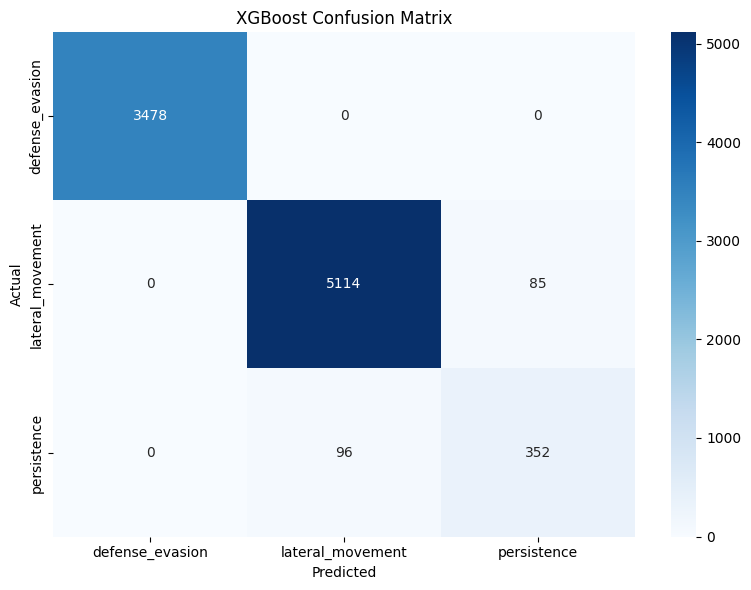

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_enc, xgb_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.tight_layout()
plt.savefig(r"C:\Research\EndpointXAI\models\confusion_matrix.png", dpi=150)
plt.show()

In [46]:
import joblib
import os

os.makedirs(r"C:\Research\EndpointXAI\models", exist_ok=True)

joblib.dump(rf_model, r"C:\Research\EndpointXAI\models\random_forest.pkl")
joblib.dump(xgb_model, r"C:\Research\EndpointXAI\models\xgboost.pkl")
joblib.dump(label_encoder, r"C:\Research\EndpointXAI\models\label_encoder.pkl")

print("All models saved! ✅")

All models saved! ✅


In [47]:
print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(f"Random Forest Accuracy: {accuracy_score(y_test_enc, rf_predictions)*100:.2f}%")
print(f"XGBoost Accuracy:       {accuracy_score(y_test_enc, xgb_predictions)*100:.2f}%")
print("="*50)

MODEL COMPARISON
Random Forest Accuracy: 98.03%
XGBoost Accuracy:       98.02%
